### 14장 모델 성능 향상 
* wine 예제

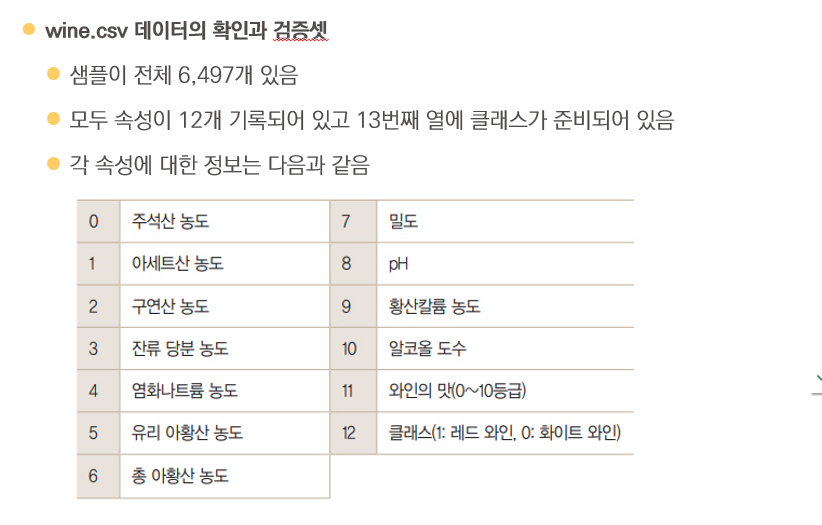

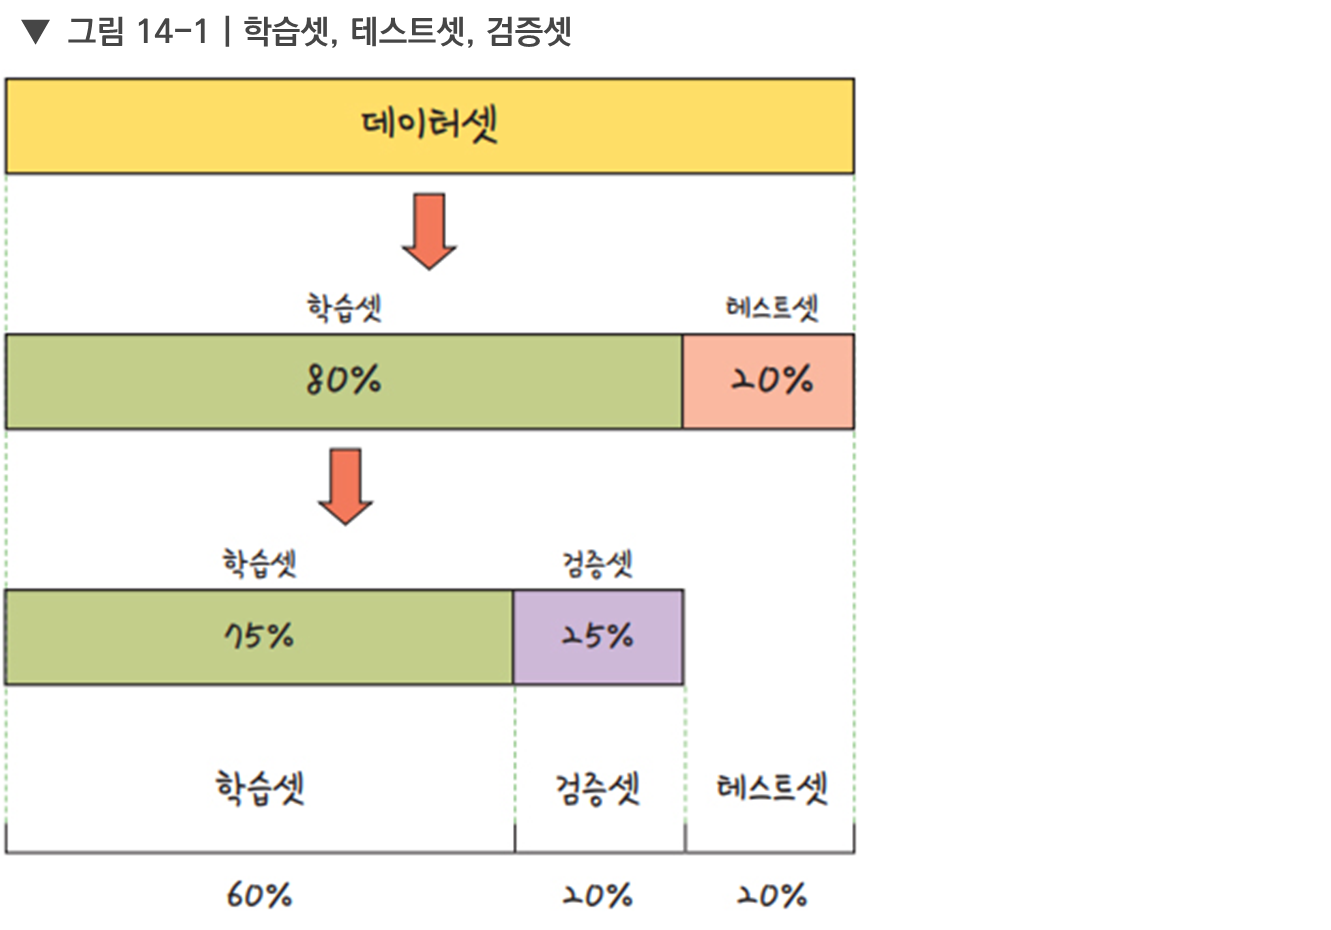

In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)  # 헤더 데이터가 없는 경우! (자동 컬럼명 부여)

# 데이터를 미리 보겠습니다.
df

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6,0
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5,0
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6,0
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7,0


In [2]:
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]
X.shape, y.shape

((6497, 12), (6497,))

In [3]:
# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5197, 12), (1300, 12), (5197,), (1300,))

In [4]:
# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
model.summary() 

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 24)                312       
                                                                 
 dense_1 (Dense)             (None, 30)                750       
                                                                 
 dense_2 (Dense)             (None, 8)                 248       
                                                                 
 dense_3 (Dense)             (None, 1)                 9         
                                                                 
Total params: 1,319
Trainable params: 1,319
Non-trainable params: 0
_________________________________________________________________


In [5]:
X_train.shape

(5197, 12)

In [6]:
X.shape[0] * 0.8

5197.6

In [7]:
5197 * 0.75

3897.75

In [8]:
5197 * 0.75 / 200 ## batch size로 나누면 step 수

19.48875

In [ ]:
# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 모델 실행 : 검증데이터 비율 지정 0.25
history = model.fit(X_train, y_train, epochs=50, batch_size=200, validation_split=0.25)

## validation_data=(X_test, y_test)
## validation_split=0.25

Epoch 1/50
20/20 [==============================] - 2s 29ms/step - loss: 3.6051 - accuracy: 0.3477 - val_loss: 0.3212 - val_accuracy: 0.9415
Epoch 2/50
20/20 [==============================] - 0s 13ms/step - loss: 0.3219 - accuracy: 0.8927 - val_loss: 0.2914 - val_accuracy: 0.9208
Epoch 3/50
20/20 [==============================] - 0s 6ms/step - loss: 0.2693 - accuracy: 0.9174 - val_loss: 0.2431 - val_accuracy: 0.9308
Epoch 4/50
20/20 [==============================] - 0s 7ms/step - loss: 0.2466 - accuracy: 0.9212 - val_loss: 0.2136 - val_accuracy: 0.9385
Epoch 5/50
20/20 [==============================] - 0s 7ms/step - loss: 0.2296 - accuracy: 0.9230 - val_loss: 0.2013 - val_accuracy: 0.9438
Epoch 6/50
20/20 [==============================] - 0s 6ms/step - loss: 0.2190 - accuracy: 0.9310 - val_loss: 0.1906 - val_accuracy: 0.9454
Epoch 7/50
20/20 [==============================] - 0s 6ms/step - loss: 0.2111 - accuracy: 0.9302 - val_loss: 0.1784 - val_accuracy: 0.9477
Epoch 8/50
20/20 [

In [10]:
# 테스트 결과 출력 (Test Data Set으로 evaluate)
score = model.evaluate(X_test, y_test)
print('Validation loss=', score[0])
print('Validation accuracy=', score[1])


41/41 [==============================] - 0s 2ms/step - loss: 0.1184 - accuracy: 0.9562
Validation loss= 0.11839763820171356
Validation accuracy= 0.9561538696289062


<Axes: >

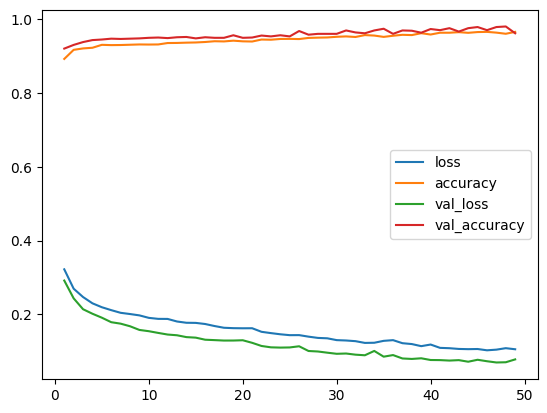

In [11]:
df_result = pd.DataFrame(history.history)
df_result[1:].plot()

## 모델 업데이트

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 24)                312       
                                                                 
 dense_9 (Dense)             (None, 30)                750       
                                                                 
 dense_10 (Dense)            (None, 8)                 248       
                                                                 
 dense_11 (Dense)            (None, 1)                 9         
                                                                 
Total params: 1,319
Trainable params: 1,319
Non-trainable params: 0
_________________________________________________________________


### 모델의 저장 및 실행

In [18]:
## 모델의 저장 조건 설정 (탐색기로 관찰할 것-폴더내 파일 지우고)
## 매 에포크마다 아래의 파일 이름으로 모델이 저장됨
model_path = './data/model/wine/{epoch:03d}-{val_accuracy:.4f}.keras'
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1)
# checkpointer = ModelCheckpoint(filepath="./data/model/wine_model.keras", verbose=1)
# checkpointer = ModelCheckpoint(filepath=model_path, verbose=1, save_best_only=True)

In [19]:
# 모델 실행
history = model.fit(X_train, y_train, epochs=200, batch_size=200, 
                    verbose=0,    # 모델이 저장되는 것만 로깅하고, 학습 과정은 로깅하지 않음
                    validation_split=0.25,
                    callbacks=[checkpointer])


Epoch 1: saving model to ./data/model/wine\001-0.9069.keras

Epoch 2: saving model to ./data/model/wine\002-0.9285.keras

Epoch 3: saving model to ./data/model/wine\003-0.9315.keras

Epoch 4: saving model to ./data/model/wine\004-0.9354.keras

Epoch 5: saving model to ./data/model/wine\005-0.9315.keras

Epoch 6: saving model to ./data/model/wine\006-0.9300.keras

Epoch 7: saving model to ./data/model/wine\007-0.9377.keras

Epoch 8: saving model to ./data/model/wine\008-0.9377.keras

Epoch 9: saving model to ./data/model/wine\009-0.9377.keras

Epoch 10: saving model to ./data/model/wine\010-0.9400.keras

Epoch 11: saving model to ./data/model/wine\011-0.9400.keras

Epoch 12: saving model to ./data/model/wine\012-0.9392.keras

Epoch 13: saving model to ./data/model/wine\013-0.9392.keras

Epoch 14: saving model to ./data/model/wine\014-0.9400.keras

Epoch 15: saving model to ./data/model/wine\015-0.9392.keras

Epoch 16: saving model to ./data/model/wine\016-0.9431.keras

Epoch 17: saving

In [20]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [21]:
df_history = pd.DataFrame(history.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,5.734742,0.314088,0.263412,0.906923
1,0.265407,0.910701,0.230695,0.928462
2,0.242422,0.922248,0.209197,0.931538
3,0.215363,0.930203,0.191088,0.935385
4,0.204830,0.930973,0.183687,0.931538
...,...,...,...,...
195,0.057570,0.982551,0.036267,0.984615
196,0.052387,0.984604,0.040012,0.986154
197,0.052346,0.984604,0.058199,0.978462
198,0.056453,0.984604,0.037550,0.985385


<Axes: >

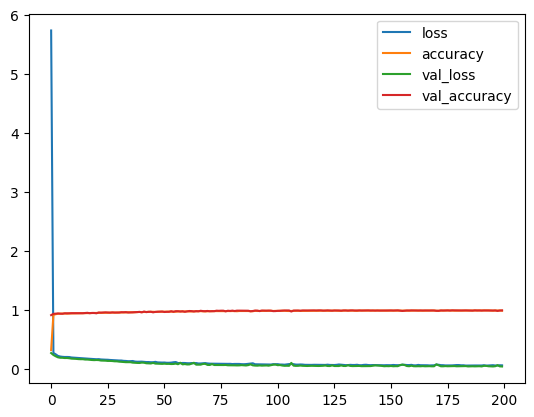

In [22]:
df_history.plot()

<Axes: >

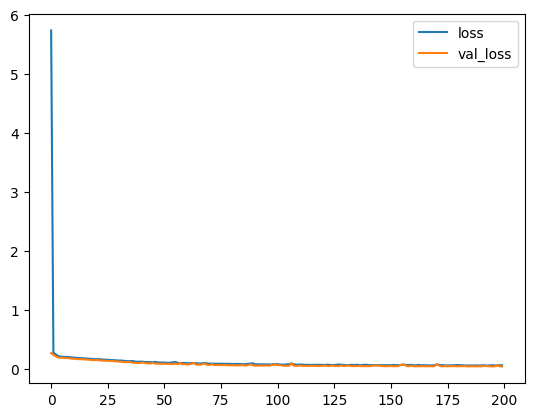

In [23]:
# loss 시각화
import matplotlib.pyplot as plt
df_history[['loss', 'val_loss']].plot()

<Axes: >

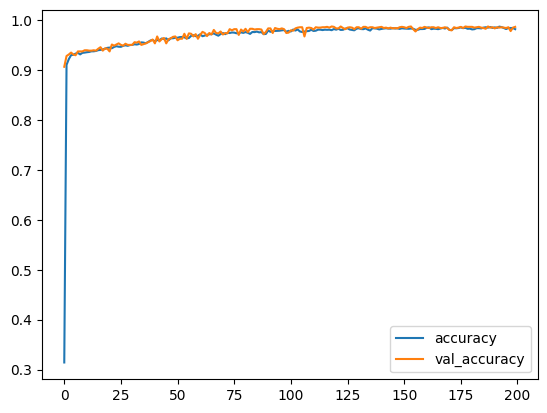

In [24]:
## accuracy 시각화
df_history[['accuracy', 'val_accuracy']].plot()

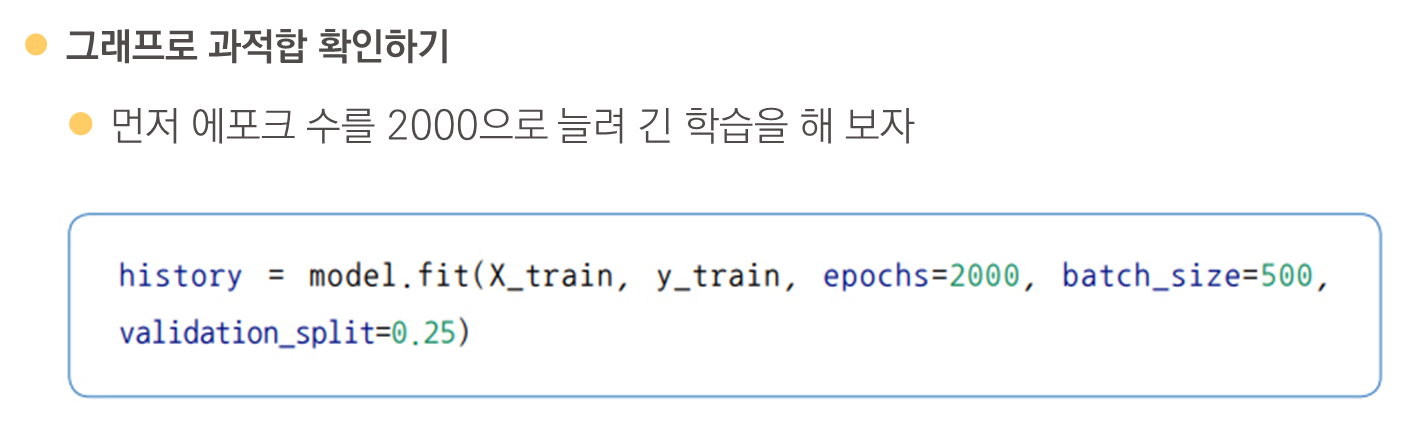

In [25]:
## save_best_only=True로 개선된 모델만 저장
## epochs 2000 -> 시간 오래 걸림 (3분 4초)
## 308번째 epoch에서 val_loss가 최저였음
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
# model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

## 모델의 저장 조건 설정
model_path = './data/model/wine_model_best.keras'
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1,
                               save_best_only=True)   # 최고 성능 모델만 저장

# 모델 실행 : 과적합이 나오도록 2000번 학습
history = model.fit(X_train, y_train, epochs=2000, batch_size=200, 
                    validation_split=0.25, verbose=0,
                    callbacks=[checkpointer])


Epoch 1: val_loss improved from inf to 0.35551, saving model to ./data/model\wine_model_best.keras

Epoch 2: val_loss improved from 0.35551 to 0.33167, saving model to ./data/model\wine_model_best.keras

Epoch 3: val_loss improved from 0.33167 to 0.31569, saving model to ./data/model\wine_model_best.keras

Epoch 4: val_loss improved from 0.31569 to 0.30419, saving model to ./data/model\wine_model_best.keras

Epoch 5: val_loss improved from 0.30419 to 0.29930, saving model to ./data/model\wine_model_best.keras

Epoch 6: val_loss improved from 0.29930 to 0.29524, saving model to ./data/model\wine_model_best.keras

Epoch 7: val_loss improved from 0.29524 to 0.28918, saving model to ./data/model\wine_model_best.keras

Epoch 8: val_loss improved from 0.28918 to 0.28615, saving model to ./data/model\wine_model_best.keras

Epoch 9: val_loss improved from 0.28615 to 0.27943, saving model to ./data/model\wine_model_best.keras

Epoch 10: val_loss improved from 0.27943 to 0.27649, saving model t

In [26]:
## 시각화
df_history = pd.DataFrame(history.history)
df_history

,loss,accuracy,val_loss,val_accuracy
0,0.419315,0.775982,0.355513,0.849231
1,0.353622,0.871696,0.331668,0.893846
2,0.337037,0.885810,0.315695,0.910000
3,0.319641,0.901976,0.304187,0.917692
4,0.309563,0.912497,0.299300,0.923077
...,...,...,...,...
1995,0.006655,0.997177,0.069981,0.990769
1996,0.004639,0.997691,0.074218,0.991538
1997,0.007577,0.997434,0.078054,0.990000
1998,0.004691,0.997691,0.074083,0.992308


<Axes: >

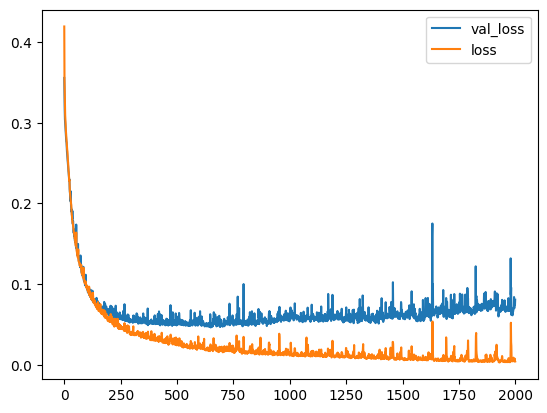

In [27]:
df_history[['val_loss', 'loss']].plot()

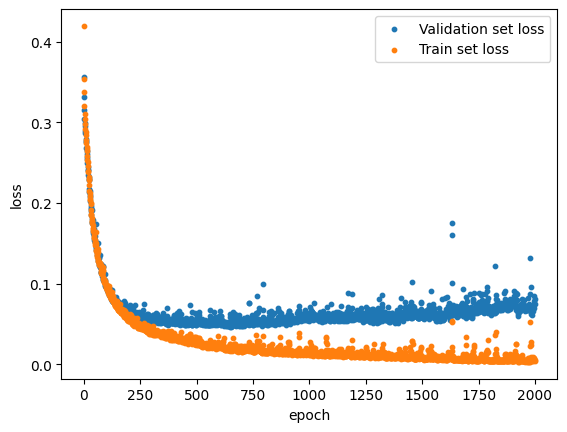

In [28]:
import numpy as np
x_len = np.arange(len(df_history))
plt.scatter(x_len, df_history['val_loss'], s=10, label='Validation set loss')
plt.scatter(x_len, df_history['loss'], s=10, label='Train set loss')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

###  학습 자동 중단 (EarlyStopping)

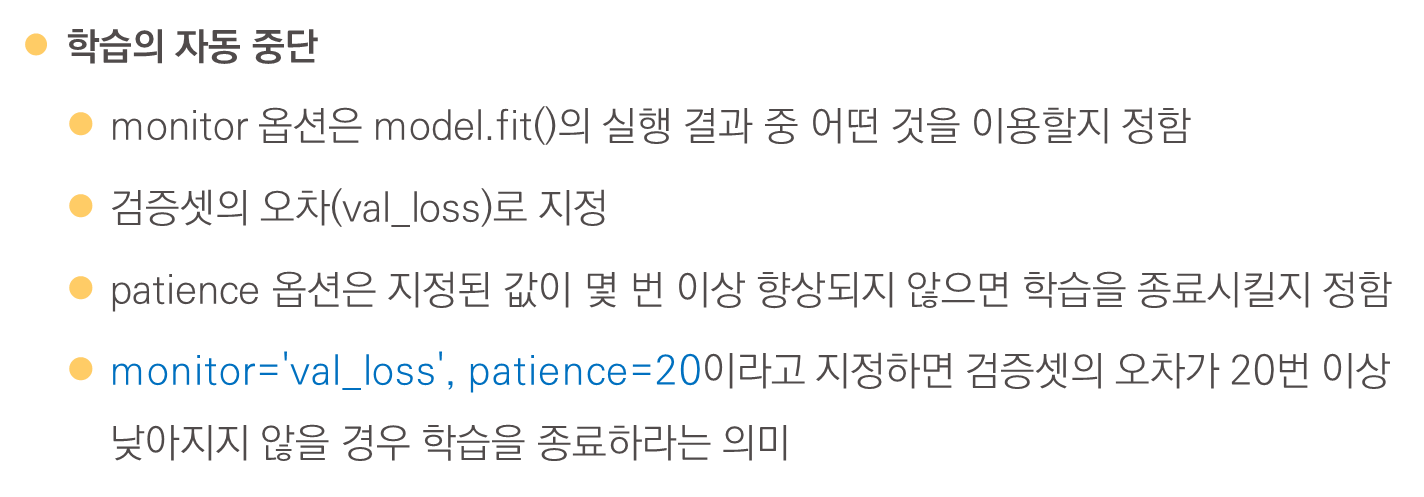

In [31]:
#############################################################
# 파일 자동 저장 : ModelCheckpoint()
# 자동 중단 : EarlyStopping()
#############################################################
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import pandas as pd

# 데이터를 입력합니다.
df = pd.read_csv('./data/wine.csv', header=None)
# 와인의 속성을 X로 와인의 분류를 y로 저장합니다.
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

# #학습셋과 테스트셋으로 나눕니다.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# 모델의 구조 설정
model = Sequential()
model.add(Dense(24, input_dim=12, activation='relu'))  # 입력 정의
model.add(Dense(30, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # 출력 정의
# model.summary() 

# 모델 컴파일 (loss, optimizer, metrics)  <- 2진 분류...
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# 학습 자동 중단 callback
early_stopping_callback = EarlyStopping(monitor='val_loss', 
                                        restore_best_weights=True,  # 가장 좋은 모델의 가중치를 복원
                                        patience=10)

## 모델의 저장 조건 설정
# model_path = 'C:/data/model/wine/{epoch:02d}-{val_accuracy:.4f}.hdf5'
## epoch나 정확도 정보를 포함하지 않고, save_best_only=True로 설정하면 최고의 모델 하나만 저장함
model_path = './data/model/wine_best_model.keras'    # 파일명이 변하지 않도록 -> 최종적으로 bestmodel만 저장
checkpointer = ModelCheckpoint(filepath=model_path, verbose=1,
                               save_best_only=True)

# 모델 실행
history = model.fit(X_train, y_train, epochs=2000, batch_size=200, 
                    validation_split=0.25, verbose=0,
                    callbacks=[checkpointer, early_stopping_callback])


Epoch 1: val_loss improved from inf to 0.73748, saving model to ./data/model\wine_best_model.keras

Epoch 2: val_loss improved from 0.73748 to 0.41321, saving model to ./data/model\wine_best_model.keras

Epoch 3: val_loss improved from 0.41321 to 0.31331, saving model to ./data/model\wine_best_model.keras

Epoch 4: val_loss improved from 0.31331 to 0.26089, saving model to ./data/model\wine_best_model.keras

Epoch 5: val_loss improved from 0.26089 to 0.23768, saving model to ./data/model\wine_best_model.keras

Epoch 6: val_loss improved from 0.23768 to 0.22692, saving model to ./data/model\wine_best_model.keras

Epoch 7: val_loss improved from 0.22692 to 0.22264, saving model to ./data/model\wine_best_model.keras

Epoch 8: val_loss improved from 0.22264 to 0.22008, saving model to ./data/model\wine_best_model.keras

Epoch 9: val_loss improved from 0.22008 to 0.21864, saving model to ./data/model\wine_best_model.keras

Epoch 10: val_loss improved from 0.21864 to 0.21547, saving model t

<Axes: >

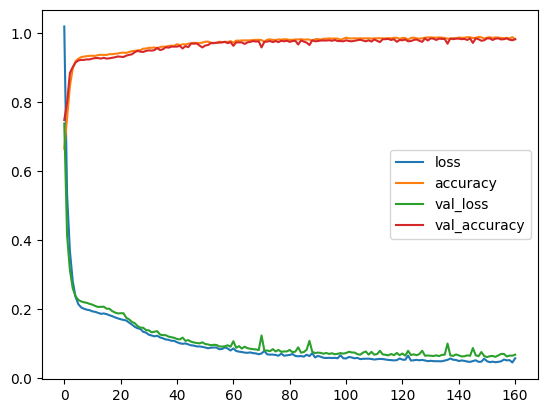

In [32]:
pd.DataFrame(history.history).plot()

In [33]:
score = model.evaluate(X_test, y_test)
print('Test accuracy:', score[1])

41/41 [==============================] - 0s 2ms/step - loss: 0.0596 - accuracy: 0.9854
Test accuracy: 0.9853846430778503
